In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image
import cv2

In [2]:
# Provide your image path here
img_path = "/Users/maneet/Documents/gissen/work/go2labs/github_2go/new/2LabsToGo-Eco/2LabsToGo-Eco-Software/Notebook/9_50_2_4_2_11_1_2_1_105.tif"

# Load image (grayscale for simplicity)
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (128, 128))

# Normalize
img = img.astype("float32") / 255.0

# Reshape for model (batch, height, width, channels)
img = np.reshape(img, (1, 128, 128, 1))

In [3]:
noise_factor = 0.5
noisy_img = img + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=img.shape)

# Clip values to valid range
noisy_img = np.clip(noisy_img, 0., 1.)

In [4]:
input_img = layers.Input(shape=(128, 128, 1))

# Encoder
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2, 2), padding='same')(x)

x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2, 2), padding='same')(x)

# Decoder
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(encoded)
x = layers.UpSampling2D((2, 2))(x)

x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)

decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

# Model
autoencoder = models.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 1)    │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
autoencoder.fit(
    noisy_img, img,
    epochs=1000,
    batch_size=1,
    verbose=1
)

Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.6566
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.5264
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.4564
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.4795
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.4930
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.4740
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.4552
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.4521
Epoch 9/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.4585
Epoch 10/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.4638
Epoch 11/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.4629
Epoch 12/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.4572
Epoch 13/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.4518
Epoch 14/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.4524
Epoch 15/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.4557
Epoch 

In [6]:
denoised_img = autoencoder.predict(noisy_img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step


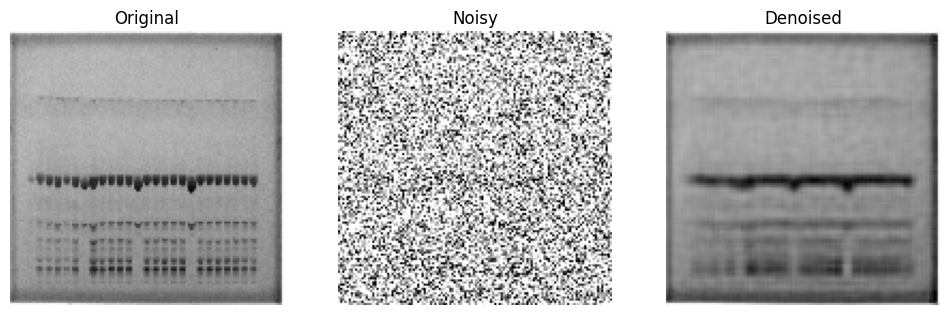

In [7]:
plt.figure(figsize=(12, 4))

# Original
plt.subplot(1, 3, 1)
plt.title("Original")
plt.imshow(img[0].reshape(128, 128), cmap='gray')
plt.axis('off')

# Noisy
plt.subplot(1, 3, 2)
plt.title("Noisy")
plt.imshow(noisy_img[0].reshape(128, 128), cmap='gray')
plt.axis('off')

# Denoised
plt.subplot(1, 3, 3)
plt.title("Denoised")
plt.imshow(denoised_img[0].reshape(128, 128), cmap='gray')
plt.axis('off')

plt.show()